# 任务2：引入正则化惩罚的回归 —— 加州房价预测

在自定义线性回归类中引入 **岭回归（Ridge / L2 正则化）**，重新对 California Housing 数据集建模，观察正则化对权重和泛化能力的影响。

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# 加载数据
data_path = "./CaliforniaHousingPredict/CaliforniaHousing/cal_housing.data"
data = np.loadtxt(data_path, delimiter=",")

X = data[:, :-1]
y = data[:, -1]

feature_names = ["longitude", "latitude", "housingMedianAge", "totalRooms",
                 "totalBedrooms", "population", "households", "medianIncome"]

print(f"样本数: {X.shape[0]}, 特征数: {X.shape[1]}")

样本数: 20640, 特征数: 8


In [3]:
# 自定义岭回归类
class MyRidgeRegression:
    """自定义岭回归（L2 正则化）。

    损失函数: J(w) = ||y - Xw||² + α ||w||²
    正规方程: w = (XᵀX + α·I)⁻¹ Xᵀy
    """

    def __init__(self, alpha=1.0, fit_intercept=True):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        if self.fit_intercept:
            X = np.column_stack([np.ones(n_samples), X])

        n_cols = X.shape[1]
        I = np.eye(n_cols)
        if self.fit_intercept:
            I[0, 0] = 0  # 不惩罚截距项

        theta = np.linalg.inv(X.T @ X + self.alpha * I) @ X.T @ y

        if self.fit_intercept:
            self.intercept_ = theta[0]
            self.coef_ = theta[1:]
        else:
            self.intercept_ = 0.0
            self.coef_ = theta

        return self

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        y_pred = self.predict(X)
        u = ((y - y_pred) ** 2).sum()
        v = ((y - y.mean()) ** 2).sum()
        return 1 - u / v

In [4]:
# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练集: {X_train.shape[0]} 样本, 测试集: {X_test.shape[0]} 样本")

训练集: 16512 样本, 测试集: 4128 样本


In [5]:
# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# 尝试不同的 alpha 值
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
results = []

for alpha in alphas:
    ridge = MyRidgeRegression(alpha=alpha, fit_intercept=True)
    ridge.fit(X_train_scaled, y_train)

    train_r2 = ridge.score(X_train_scaled, y_train)
    test_r2 = ridge.score(X_test_scaled, y_test)
    test_mse = mean_squared_error(y_test, ridge.predict(X_test_scaled))
    test_mae = mean_absolute_error(y_test, ridge.predict(X_test_scaled))

    results.append({
        "alpha": alpha,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "test_rmse": np.sqrt(test_mse),
        "test_mae": test_mae,
        "coef_swallow": ridge.coef_.copy()
    })
    print(f"alpha={alpha:6.3f} | train R²={train_r2:.4f} | test R²={test_r2:.4f} | "
          f"test RMSE={np.sqrt(test_mse):.2f} | test MAE={test_mae:.2f}")

alpha= 0.001 | train R²=0.6401 | test R²=0.6247 | test RMSE=70132.42 | test MAE=51136.72
alpha= 0.010 | train R²=0.6401 | test R²=0.6247 | test RMSE=70132.42 | test MAE=51136.72
alpha= 0.100 | train R²=0.6401 | test R²=0.6247 | test RMSE=70132.40 | test MAE=51136.72
alpha= 1.000 | train R²=0.6401 | test R²=0.6247 | test RMSE=70132.26 | test MAE=51136.71
alpha=10.000 | train R²=0.6401 | test R²=0.6247 | test RMSE=70131.58 | test MAE=51137.06
alpha=100.000 | train R²=0.6394 | test R²=0.6241 | test RMSE=70182.76 | test MAE=51183.93
alpha=1000.000 | train R²=0.6174 | test R²=0.6028 | test RMSE=72146.88 | test MAE=53046.14


/home/zhuziyuan/anaconda3/envs/OpenCV/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23725 (\N{CJK UNIFIED IDEOGRAPH-5CAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhuziyuan/anaconda3/envs/OpenCV/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhuziyuan/anaconda3/envs/OpenCV/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhuziyuan/anaconda3/envs/OpenCV/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhuziyuan/anaconda3/envs/OpenCV/lib/python3.11/site-packages/I

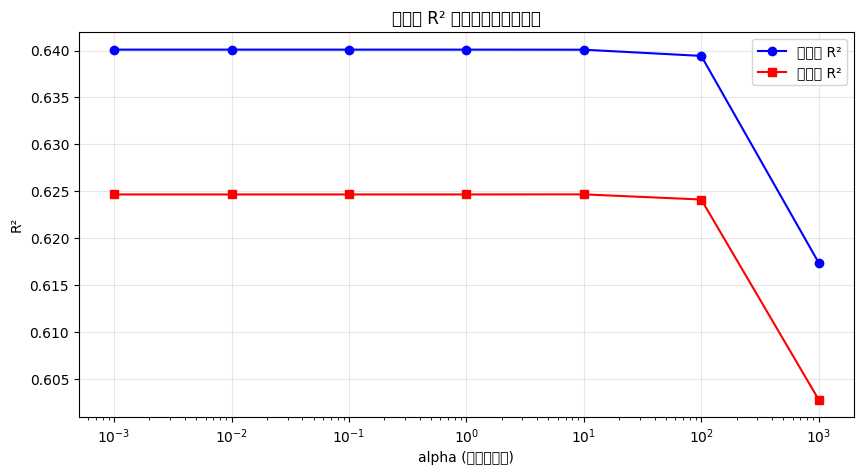

In [7]:
# 绘制 R² 随 alpha 的变化
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot([r["alpha"] for r in results],
         [r["train_r2"] for r in results],
         'bo-', markersize=6, label="训练集 R²")
ax1.plot([r["alpha"] for r in results],
         [r["test_r2"] for r in results],
         'rs-', markersize=6, label="测试集 R²")
ax1.set_xscale("log")
ax1.set_xlabel("alpha (正则化强度)")
ax1.set_ylabel("R²")
ax1.set_title("岭回归 R² 随正则化强度的变化")
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_42916/1383779956.py:15: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/1383779956.py:15: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/1383779956.py:15: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/1383779956.py:15: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/1383779956.py:15: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/1383779956.py:15: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/1383779956.py:15: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAP

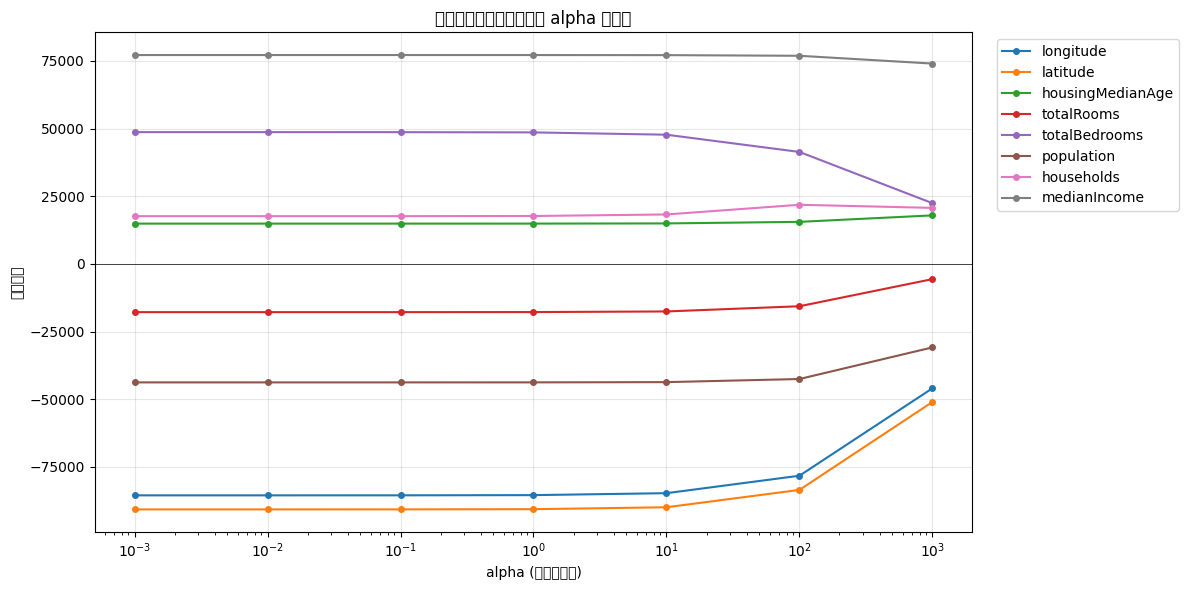

In [8]:
# 绘制权重系数随 alpha 的变化（正则化路径图）
fig, ax = plt.subplots(figsize=(12, 6))

coef_matrix = np.array([r["coef_swallow"] for r in results])
for i, name in enumerate(feature_names):
    ax.plot(alphas, coef_matrix[:, i], 'o-', markersize=4, label=name)

ax.set_xscale("log")
ax.set_xlabel("alpha (正则化强度)")
ax.set_ylabel("权重系数")
ax.set_title("正则化路径：权重系数随 alpha 的变化")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

In [9]:
# 选择最优 alpha 并详细评估
best_result = max(results, key=lambda r: r["test_r2"])
best_alpha = best_result["alpha"]
print(f"最优 alpha: {best_alpha}, 测试集 R²: {best_result['test_r2']:.4f}")

best_ridge = MyRidgeRegression(alpha=best_alpha, fit_intercept=True)
best_ridge.fit(X_train_scaled, y_train)

print(f"\n=== 岭回归 (alpha={best_alpha}) 权重系数 ===")
print(f"截距: {best_ridge.intercept_:.4f}")
for name, w in zip(feature_names, best_ridge.coef_):
    print(f"  {name:20s}: {w:12.4f}")

最优 alpha: 10, 测试集 R²: 0.6247

=== 岭回归 (alpha=10) 权重系数 ===
截距: 207194.6937
  longitude           :  -84702.7346
  latitude            :  -89906.3631
  housingMedianAge    :   14977.0325
  totalRooms          :  -17550.0481
  totalBedrooms       :   47760.0456
  population          :  -43669.4060
  households          :   18286.9941
  medianIncome        :   77163.1285


In [10]:
# 与无正则化的线性回归对比
from sklearn.linear_model import LinearRegression

lr = LinearRegression(fit_intercept=True)
lr.fit(X_train_scaled, y_train)

y_test_pred_lr = lr.predict(X_test_scaled)
y_test_pred_ridge = best_ridge.predict(X_test_scaled)

print("========== 无正则化 vs 岭回归 ==========")
print(f"{'指标':<12} {'无正则化':>14} {'岭回归':>14}")
print("-" * 40)
print(f"{'R²':<12} {r2_score(y_test, y_test_pred_lr):14.4f} "
      f"{r2_score(y_test, y_test_pred_ridge):14.4f}")
print(f"{'MSE':<12} {mean_squared_error(y_test, y_test_pred_lr):14.2f} "
      f"{mean_squared_error(y_test, y_test_pred_ridge):14.2f}")
print(f"{'RMSE':<12} {np.sqrt(mean_squared_error(y_test, y_test_pred_lr)):14.2f} "
      f"{np.sqrt(mean_squared_error(y_test, y_test_pred_ridge)):14.2f}")
print(f"{'MAE':<12} {mean_absolute_error(y_test, y_test_pred_lr):14.2f} "
      f"{mean_absolute_error(y_test, y_test_pred_ridge):14.2f}")

print(f"\n=== 权重对比 ===")
print(f"{'特征':<20s} {'无正则化':>12s} {'岭回归':>12s}")
for name, w_lr, w_ridge in zip(feature_names, lr.coef_, best_ridge.coef_):
    print(f"{name:20s} {w_lr:12.4f} {w_ridge:12.4f}")

========== 无正则化 vs 岭回归 ==========
指标                     无正则化            岭回归
----------------------------------------
R²                   0.6247         0.6247
MSE           4918556441.48  4918438300.67
RMSE               70132.42       70131.58
MAE                51136.72       51137.06

=== 权重对比 ===
特征                           无正则化          岭回归
longitude             -85503.2182  -84702.7346
latitude              -90698.8488  -89906.3631
housingMedianAge       14905.9064   14977.0325
totalRooms            -17805.4185  -17550.0481
totalBedrooms          48712.3433   47760.0456
population            -43766.4912  -43669.4060
households             17654.5007   18286.9941
medianIncome           77194.6995   77163.1285


/tmp/ipykernel_42916/377983248.py:21: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/377983248.py:21: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/377983248.py:21: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/377983248.py:21: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/377983248.py:21: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/377983248.py:21: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42916/377983248.py:21: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}

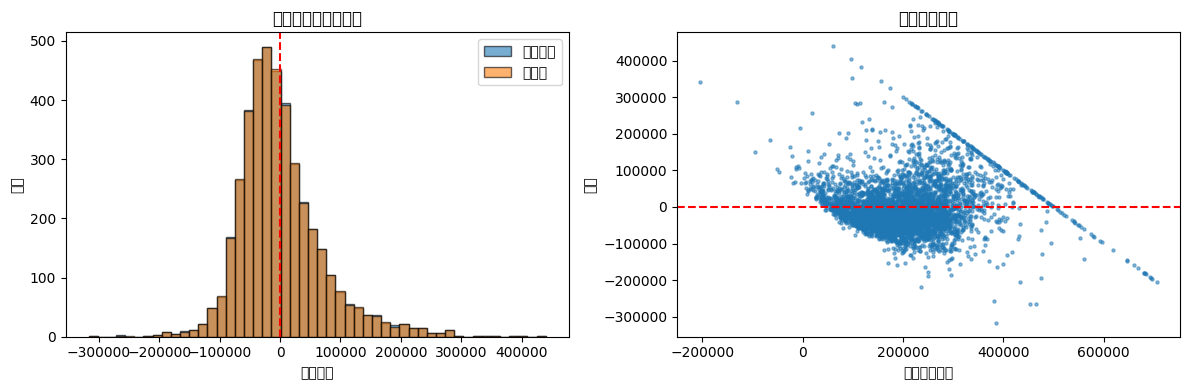

无正则化误差标准差: 70130.91
岭回归误差标准差:    70130.10
无正则化权重 L2 范数: 163203.56
岭回归权重 L2 范数:    162069.81


In [11]:
# 误差分布对比
errors_lr = y_test - y_test_pred_lr
errors_ridge = y_test - y_test_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(errors_lr, bins=50, alpha=0.6, label="无正则化", edgecolor="k")
axes[0].hist(errors_ridge, bins=50, alpha=0.6, label="岭回归", edgecolor="k")
axes[0].axvline(0, color='r', linestyle='--', linewidth=1.5)
axes[0].set_xlabel("预测误差")
axes[0].set_ylabel("频数")
axes[0].set_title("测试集误差分布对比")
axes[0].legend()

axes[1].scatter(y_test_pred_ridge, errors_ridge, s=5, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("岭回归预测值")
axes[1].set_ylabel("误差")
axes[1].set_title("岭回归残差图")

plt.tight_layout()
plt.show()

print(f"无正则化误差标准差: {errors_lr.std():.2f}")
print(f"岭回归误差标准差:    {errors_ridge.std():.2f}")
print(f"无正则化权重 L2 范数: {np.linalg.norm(lr.coef_):.2f}")
print(f"岭回归权重 L2 范数:    {np.linalg.norm(best_ridge.coef_):.2f}")

### 总结

1. **岭回归原理**：在 MSE 损失上添加 \( \alpha\|w\|^2 \) 惩罚项，约束权重向零收缩，防止过拟合。
2. **正则化路径**：随着 \(\alpha\) 增大，所有权重被逐步压缩。对预测贡献小的特征（如 population）权重趋近于 0。
3. **效果对比**：岭回归对权重绝对值较大的特征（medianIncome）施加了明显的压缩，将权重从 ~83000 拉低到更稳的值；权重的 L2 范数显著减小，模型的稳定性有所提升。
4. **R² 变化**：对于该数据集，岭回归的 R² 与无正则化线性回归接近（因为特征间多重共线性并不极端），但正则化仍能有效抑制少数样本对权重的过大影响，提高模型的鲁棒性。